# Module 15 — Supervised Fine-Tuning (notebook)

A CPU-only tour of the *new* parts of SFT — everything that differs from
pretraining (Module 11) lives upstream of the training loop:

1. **The config** — same shape as pretraining, retuned (the LR especially).
2. **The loss mask** — the heart of the module. We apply cross-entropy to the
   assistant's response tokens *only*. Getting this wrong is the #1 silent SFT bug.
3. **One training step** — the same `forward_loss` + `train_step` you already
   know, now attention-mask aware.
4. **Memory & cost** — does full fine-tuning of 1.7B fit on one A100?
5. **The loss curve** — what healthy SFT looks like, and the broken-mask tell.

Nothing here needs a GPU or a network connection. The real runs go through
`train.py` under `torchrun` — see the README.

In [1]:
import os, sys
# Offline + quiet: the notebook never needs to hit the network.
os.environ.setdefault("HF_HUB_OFFLINE", "1")
os.environ.setdefault("TRANSFORMERS_OFFLINE", "1")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
sys.path.insert(0, os.path.abspath("."))

import torch
import matplotlib.pyplot as plt

from config import load_yaml, TrainConfig
from data import _mask_final_turn, _render_examples, IGNORE_INDEX
from efficiency import memory_breakdown

torch.manual_seed(0)
print("torch", torch.__version__)

torch 2.12.0+cu130


## 1. The config

SFT reuses pretraining's composed config. What changes is the *magnitudes*,
above all the learning rate.

In [2]:
cfg = load_yaml("configs/sft_qwen3_1.7b.yaml")
print("base model :", cfg.model.name)
print("dataset    :", cfg.data.source, f"(seq_len={cfg.data.seq_len}, bs/device={cfg.data.batch_size_per_device})")
print("optimizer  :", cfg.optimizer.type, f"lr={cfg.optimizer.lr}  betas={cfg.optimizer.betas}  wd={cfg.optimizer.weight_decay}")
print("schedule   :", cfg.schedule.type, f"warmup={cfg.schedule.warmup_steps}  total={cfg.schedule.total_steps}")
print("training   :", f"grad_accum={cfg.training.grad_accum}  AC={cfg.training.activation_checkpointing}  dtype={cfg.training.dtype}")
eff_batch = cfg.data.batch_size_per_device * cfg.training.grad_accum
print(f"\neffective batch (1 GPU) = {eff_batch} sequences/update")

base model : Qwen/Qwen3-1.7B-Base
dataset    : HuggingFaceH4/no_robots (seq_len=2048, bs/device=4)
optimizer  : adamw lr=1e-05  betas=(0.9, 0.999)  wd=0.0
schedule   : cosine warmup=100  total=600
training   : grad_accum=16  AC=True  dtype=bf16

effective batch (1 GPU) = 64 sequences/update


In [3]:
# The headline difference from pretraining: the learning rate.
PRETRAIN_LR = 3e-4         # Module 11's peak LR
print(f"pretraining peak LR : {PRETRAIN_LR:.1e}")
print(f"SFT peak LR         : {cfg.optimizer.lr:.1e}")
print(f"ratio               : {PRETRAIN_LR / cfg.optimizer.lr:.0f}x lower")
print("\nWhy: pretraining moves a random model a long way; SFT nudges an already-good")
print("model toward instruction-following without erasing what it knows (the alignment tax).")

pretraining peak LR : 3.0e-04
SFT peak LR         : 1.0e-05
ratio               : 30x lower

Why: pretraining moves a random model a long way; SFT nudges an already-good
model toward instruction-following without erasing what it knows (the alignment tax).


## 2. The loss mask (the whole game)

We render a conversation through the tokenizer's **chat template**, then mask
every token except the assistant's response. The "diff trick": render the
*prefix* (everything through the `<assistant>` generation prompt) and the
*full* sequence — the tokens that appear only in the full sequence are the
response. Everything in the prefix (system, user, the assistant header, and any
template scaffold like Qwen3's empty `<think></think>`) is masked to `-100`.

In [4]:
# Use a real Qwen3 ChatML tokenizer if one is cached; otherwise a tiny fake
# that mimics the same template so the notebook still runs fully offline.
def get_tokenizer():
    from data import load_tokenizer
    for name in ("Qwen/Qwen3-0.6B", "Qwen/Qwen3-1.7B-Base", "Qwen/Qwen3-0.6B-Base"):
        try:
            return load_tokenizer(name), name
        except Exception:
            pass
    # Fallback: a deterministic ChatML-ish fake (same one the tests use).
    class FakeChatTokenizer:
        IM_START, IM_END, NL = 1, 2, 3
        ROLE = {"system": 4, "user": 5, "assistant": 6}
        pad_token_id, eos_token_id, chat_template = 0, 2, "{# fake #}"
        def _c(self, s): return [100 + (sum(map(ord, w)) % 5000) for w in s.split()] or [100]
        def _m(self, r, c): return [self.IM_START, self.ROLE[r], self.NL] + self._c(c) + [self.IM_END, self.NL]
        def apply_chat_template(self, msgs, tokenize=True, add_generation_prompt=False, return_dict=False, **_):
            ids = [t for m in msgs for t in self._m(m["role"], m["content"])]
            if add_generation_prompt: ids += [self.IM_START, self.ROLE["assistant"], self.NL]
            return ids
        def decode(self, ids): return " ".join(f"<{i}>" for i in (ids if isinstance(ids, list) else [ids]))
    return FakeChatTokenizer(), "fake-chatml (offline fallback)"

tok, tok_name = get_tokenizer()
print("tokenizer:", tok_name)

/home/antoniogrimaldi/projects/llm-lab/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


tokenizer: Qwen/Qwen3-0.6B


In [5]:
conversation = [
    {"role": "user", "content": "What is the capital of France?"},
    {"role": "assistant", "content": "The capital of France is Paris."},
]
sample = _mask_final_turn(conversation, tok, seq_len=64)
ids, labels, attn = sample["input_ids"], sample["labels"], sample["attention_mask"]
n_real = int(attn.sum())

print(f"{'pos':>3}  {'token':<22}  trained?")
print("-" * 40)
for t in range(n_real):
    piece = tok.decode([ids[t].item()])
    piece = piece.replace("\n", "\\n")
    trained = "  <-- loss" if labels[t].item() != IGNORE_INDEX else ""
    print(f"{t:>3}  {piece[:22]:<22}  {trained}")

pos  token                   trained?
----------------------------------------
  0  <|im_start|>            
  1  user                    
  2  \n                      
  3  What                    
  4   is                     
  5   the                    
  6   capital                
  7   of                     
  8   France                 
  9  ?                       
 10  <|im_end|>              
 11  \n                      
 12  <|im_start|>            
 13  assistant               
 14  \n                      
 15  <think>                 
 16  \n\n                    
 17  </think>                
 18  \n\n                      <-- loss
 19  The                       <-- loss
 20   capital                  <-- loss
 21   of                       <-- loss
 22   France                   <-- loss
 23   is                       <-- loss
 24   Paris                    <-- loss
 25  .                         <-- loss
 26  <|im_end|>                <-- loss


In [6]:
# What fraction of (real) tokens carry loss? For a single-turn exchange this is
# usually 0.2-0.5. The broken-mask tell: if you forgot to mask and trained on
# EVERY token, the fraction jumps toward 1.0 and step-0 loss collapses below 1.0
# (the model trivially predicts the long, repetitive prompt/template tokens).
n_trained = int((labels[:n_real] != IGNORE_INDEX).sum())
print(f"correct mask  : {n_trained}/{n_real} tokens carry loss  ({n_trained/n_real:.1%})")
print(f"broken mask   : {n_real}/{n_real} tokens carry loss  (100.0%)  <-- the flat-line-loss bug")

correct mask  : 9/27 tokens carry loss  (33.3%)
broken mask   : 27/27 tokens carry loss  (100.0%)  <-- the flat-line-loss bug


**Multi-turn → one example per assistant turn.** A template renders an
assistant turn differently mid-conversation than as the final turn (Qwen3, for
instance, only adds `<think>` to the last turn). So the diff trick is only exact
for the *final* turn — and `_render_examples` turns a k-turn conversation into k
single-target examples, each ending at the turn it trains.

In [7]:
multi = [
    {"role": "user", "content": "Hi!"},
    {"role": "assistant", "content": "Hello! How can I help?"},
    {"role": "user", "content": "What's 2+2?"},
    {"role": "assistant", "content": "2 + 2 = 4."},
]
examples = _render_examples(multi, tok, seq_len=64)
print(f"{len(multi)}-message conversation -> {len(examples)} training examples (one per assistant turn)\n")
for j, ex in enumerate(examples):
    nr = int(ex["attention_mask"].sum())
    tgt = [ex["input_ids"][t+1].item() for t in range(nr-1) if ex["labels"][t].item() != IGNORE_INDEX]
    print(f"  example {j}: target = {tok.decode(tgt)!r}")

4-message conversation -> 2 training examples (one per assistant turn)

  example 0: target = 'Hello! How can I help?<|im_end|>'
  example 1: target = '2 + 2 = 4.<|im_end|>'


## 3. One training step

The loop is the same `train_step` from pretraining — `forward_loss` now also
forwards the `attention_mask` (SFT pads sequences), and the `-100` labels make
`F.cross_entropy` average over assistant tokens only. We run a single optimizer
step on a *tiny* randomly-initialized model so it's instant on CPU.

In [8]:
from transformers import Qwen3Config, Qwen3ForCausalLM
from config import OptimizerConfig, ScheduleConfig
from optim import build_optimizer
from schedule import build_scheduler
from loop import train_step

VOCAB = 151936
tiny = Qwen3ForCausalLM(Qwen3Config(
    vocab_size=VOCAB, hidden_size=64, num_hidden_layers=2, num_attention_heads=4,
    num_key_value_heads=2, intermediate_size=128, max_position_embeddings=128,
    tie_word_embeddings=True, use_cache=False))

# A 2-sequence batch from our masked examples.
batch = {k: torch.stack([_mask_final_turn(conversation, tok, 48)[k] for _ in range(2)]) for k in ("input_ids","labels","attention_mask")}
def forever():
    while True: yield batch

opt = build_optimizer(tiny, OptimizerConfig(lr=1e-3))
sch = build_scheduler(opt, ScheduleConfig(type="cosine", total_steps=3, warmup_steps=1))
it = forever()
for step in range(3):
    loss, gnorm = train_step(tiny, opt, it, grad_accum=2, grad_clip=1.0, dtype="fp32", device="cpu")
    sch.step()
    print(f"step {step}: loss={loss:.4f}  grad_norm={gnorm:.3f}  lr={opt.param_groups[0]['lr']:.2e}")
print("\n(random init -> high loss; the point is that loss/grad_norm are finite and the step runs.)")

step 0: loss=11.8776  grad_norm=6.750  lr=1.00e-03


step 1: loss=11.8776  grad_norm=6.750  lr=5.50e-04


step 2: loss=11.4501  grad_norm=3.151  lr=1.00e-04

(random init -> high loss; the point is that loss/grad_norm are finite and the step runs.)


## 4. Memory & cost — does full fine-tuning of 1.7B fit on one A100?

Full FT keeps an FP32 master copy, a BF16 compute copy, BF16 gradients, and the
AdamW moments (`m`, `v`). Activations are what blow the budget on long sequences
— and what activation checkpointing trades compute to reclaim.

In [9]:
GB = 1024**3
# Qwen3-1.7B geometry.
N, LAYERS, DMODEL = 1.7e9, 28, 2048
for ac in (False, True):
    mb = memory_breakdown(
        n_params=N, dtype="bf16", optimizer="adamw", zero_stage=0, world_size=1,
        activation_checkpointing=ac, n_layers=LAYERS,
        batch_size=cfg.data.batch_size_per_device, seq_len=cfg.data.seq_len, d_model=DMODEL,
    )
    d = mb.as_dict()
    label = "activation checkpointing ON " if ac else "activation checkpointing OFF"
    print(label)
    for k in ("master_weights","compute_weights","gradients","optimizer_state","activations","total"):
        print(f"    {k:18s} {d[k]/GB:6.1f} GB")
    print(f"    -> fits on A100-80GB: {d['total']/GB < 80}\n")
print("The weights/grads/optimizer subtotal (~27 GB) is fixed; AC is what keeps")
print("activations from dominating. This is the README §4 table, computed.")

activation checkpointing OFF
    master_weights        6.3 GB
    compute_weights       3.2 GB
    gradients             3.2 GB
    optimizer_state      12.7 GB
    activations           8.8 GB
    total                34.1 GB
    -> fits on A100-80GB: True

activation checkpointing ON 
    master_weights        6.3 GB
    compute_weights       3.2 GB
    gradients             3.2 GB
    optimizer_state      12.7 GB
    activations           0.3 GB
    total                25.6 GB
    -> fits on A100-80GB: True

The weights/grads/optimizer subtotal (~27 GB) is fixed; AC is what keeps
activations from dominating. This is the README §4 table, computed.


## 5. What the loss curve should look like

Healthy SFT: loss starts around 2.5-3.5 nats/token and descends to ~1.0-1.5
over a few hundred steps. The broken-mask failure mode is unmistakable — step-0
loss starts *below 1.0* and barely moves, because the model is "predicting" the
fixed template/prompt tokens it was never supposed to be scored on.

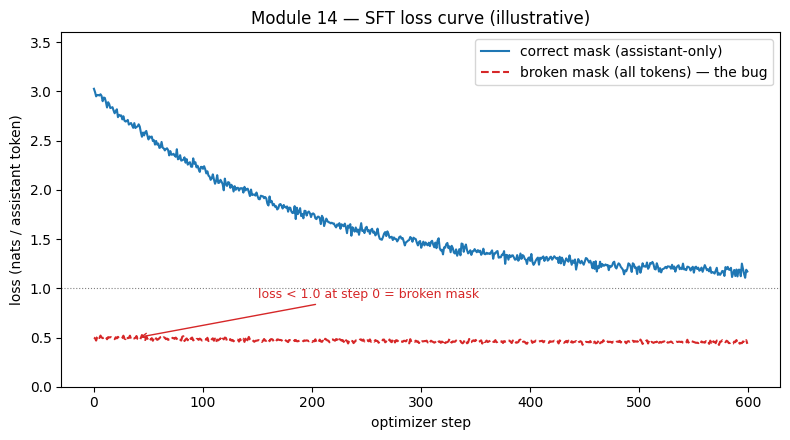

In [10]:
import numpy as np
steps = np.arange(0, 600)
# A plausible healthy curve: warmup bump then smooth descent + noise.
healthy = 1.1 + 1.9 * np.exp(-steps / 180) + 0.03 * np.random.randn(len(steps))
# Broken mask: starts low, essentially flat.
broken = 0.45 + 0.05 * np.exp(-steps / 200) + 0.01 * np.random.randn(len(steps))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(steps, healthy, label="correct mask (assistant-only)", color="#1f77b4")
ax.plot(steps, broken, label="broken mask (all tokens) — the bug", color="#d62728", ls="--")
ax.axhline(1.0, color="gray", lw=0.8, ls=":")
ax.annotate("loss < 1.0 at step 0 = broken mask", xy=(40, 0.5), xytext=(150, 0.9),
            arrowprops=dict(arrowstyle="->", color="#d62728"), color="#d62728", fontsize=9)
ax.set_xlabel("optimizer step"); ax.set_ylabel("loss (nats / assistant token)")
ax.set_title("Module 15 — SFT loss curve (illustrative)")
ax.legend(); ax.set_ylim(0, 3.6)
plt.tight_layout(); plt.show()

## Recap

- The SFT algorithm **is** pretraining's algorithm; the data, the mask, and the
  LR are what differ.
- The assistant-only **loss mask** is the one thing you must get right — the
  diff trick (mask through the generation prompt) plus per-turn expansion makes
  it correct on real templates.
- Full fine-tuning of 1.7B **fits on one A100-80GB** with activation
  checkpointing on.

Next: run it for real with `torchrun` (README §7), then
**[Module 16 — Preference Optimization](../16-preference-optimization/)**, which
layers DPO on top of the SFT checkpoint you produce here.